# (정리) NAS, Zoph2016
> 작성완료 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [스터디, 논문리뷰]

`-` 아래논문의 리뷰임 
- Zoph, B., \& Le, Q. V. (2016). Neural architecture search with reinforcement learning. arXiv preprint arXiv:1611.01578. 

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import requests 
exec(requests.get("http://miruetoto.github.io/source/datahandling.py").text)
from matplotlib import pyplot as plt
print(tf.__version__)
checkgpu()

2.2.0
GPU check 4 TensorFlow: /device:GPU:0


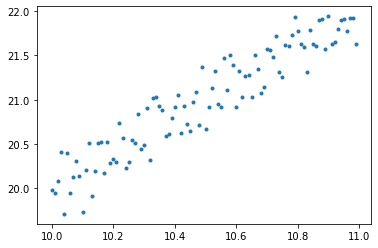

In [8]:
x=np.array(range(1000,1100))/100
y=2*x+0.2*np.random.randn(100)
plt.plot(x,y,'.')

In [17]:
modelenv = tf.keras.models.Sequential()
modelenv.add(keras.layers.Dense(1, input_dim=1,activation='linear'))
modelenv.add(keras.layers.Dense(1,activation='linear'))
modelenv.add(keras.layers.Dense(1,activation='sigmoid'))
modelenv.compile(loss='mean_squared_error', optimizer='Adam')
hist = modelenv.fit(x, y, epochs=200)

Epoch 1/200
4/4 [==============================] - 0s 796us/step - loss: 407.0744
Epoch 2/200
4/4 [==============================] - 0s 775us/step - loss: 406.6873
Epoch 3/200
4/4 [==============================] - 0s 653us/step - loss: 406.3139
Epoch 4/200
4/4 [==============================] - 0s 750us/step - loss: 405.9553
Epoch 5/200
4/4 [==============================] - 0s 735us/step - loss: 405.6118
Epoch 6/200
4/4 [==============================] - 0s 802us/step - loss: 405.2848
Epoch 7/200
4/4 [==============================] - 0s 697us/step - loss: 404.9743
Epoch 8/200
4/4 [==============================] - 0s 762us/step - loss: 404.6805
Epoch 9/200
4/4 [==============================] - 0s 662us/step - loss: 404.4035
Epoch 10/200
4/4 [==============================] - 0s 626us/step - loss: 404.1425
Epoch 11/200
4/4 [==============================] - 0s 686us/step - loss: 403.8973
Epoch 12/200
4/4 [==============================] - 0s 676us/step - loss: 403.6674
Epoch 13/200


In [18]:
r00=0.0535
r01=91.1902
r10=0.3961
r11=34.4771

def J(x):
    c=x[0];w1=x[1];b1=x[2];w2=x[3];b2=x[4]
    
    J00=r00 * 1/(1+np.exp(c)) * 1/(1+np.exp(w2*np.tanh(w1*0+b1)+b2))
    J01=r01 * 1/(1+np.exp(c)) * np.exp(w2*np.tanh(w1*0+b1)+b2)/(1+np.exp(w2*np.tanh(w1*0+b1)+b2))
    J10=r10 * np.exp(c)/(1+np.exp(c)) * 1/(1+np.exp(np.exp(w2*np.tanh(w1*1+b1)+b2)))
    J11=r11 * np.exp(c)/(1+np.exp(c)) * np.exp(w2*np.tanh(w1*1+b1)+b2)/(1+np.exp(w2*np.tanh(w1*1+b1)+b2)) 
    J=J00+J01+J10+J11
    return J 

def grd(f,x):
    h=1e-4
    grad=np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx]=tmp_val +h 
        fxh1=f(x)
        x[idx]=tmp_val -h
        fxh2=f(x)
        grad[idx]=(fxh1-fxh2)/(2*h)
        x[idx]=tmp_val 
    return grad   


In [19]:
# global min으로 수렴 
para=np.array([-8,77,77,0,-8]) 
print("[step 1]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para)) 
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([-8,77,77,0,-11]) 
print("[step 2]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([-8,77,77,0,-16]) 
print("[step 3]")
print("θ:=(c,w1,b1,w2,b2)=",para)
print("J(θ):",J(para))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")


[step 1]
θ:=(c,w1,b1,w2,b2)= [-8 77 77  0 -8]
J(θ): 0.0841047960343998
dJ/dθ:  [  0   0   0   0 262]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.     0.     0.     0.     0.0262]
--------------------------
[step 2]
θ:=(c,w1,b1,w2,b2)= [ -8  77  77   0 -11]
J(θ): 0.055070269438824114
dJ/dθ:  [ 0  0  0  0 13]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.     0.     0.     0.     0.0013]
--------------------------
[step 3]
θ:=(c,w1,b1,w2,b2)= [ -8  77  77   0 -16]
J(θ): 0.05355872880266694
dJ/dθ:  [0 0 0 0 0]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0. 0. 0. 0. 0.]
--------------------------


In [20]:
# saddle point 로 수렴 
para=np.array([5,1,1,5,5]) 
print("[step 1]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para)) 
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([10,0,0,3,3]) 
print("[step 2]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([15,0,0,3,-2]) 
print("[step 3]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([15,0,0,3,-9]) 
print("[step 4]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([15,0,0,3,-15]) 
print("[step 5]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")

[step 1]
θ:=(c,w1,b1,w2,b2)= [5 1 1 5 5]
J(θ): 34.85472007147423
dJ/dθ:  [-3201    16    36    15    16]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [-0.3201  0.0016  0.0036  0.0015  0.0016]
--------------------------
[step 2]
θ:=(c,w1,b1,w2,b2)= [10  0  0  3  3]
J(θ): 32.844446092466185
dJ/dθ:  [  -21     0     0     0 12373]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [-0.0021  0.      0.      0.      1.2373]
--------------------------
[step 3]
θ:=(c,w1,b1,w2,b2)= [15  0  0  3 -2]
J(θ): 4.294441929836379
dJ/dθ:  [    0     0     0     0 25699]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.     0.     0.     0.     2.5699]
--------------------------
[step 4]
θ:=(c,w1,b1,w2,b2)= [15  0  0  3 -9]
J(θ): 0.2022920244041837
dJ/dθ:  [ 0  0  0  0 36]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.     0.     0.     0.     0.0036]
--------------------------
[step 5]
θ:=(c,w1,b1,w2,b2)= [ 15   0   0   3 -15]
J(θ): 0.198060472116835
dJ/dθ:  [0 0 0 0 0]
dθ: [0.0001, 0.00